<a href="https://colab.research.google.com/github/Elwing-Chou/ml0903/blob/main/ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- 筆記語法: markdown語法
- Kaggle網站
- CSV(Comma-Separated Values)
    - 統計學標準表格格式
- 機器學習
    - x(輸入) y(答案)
        - 根據y不一樣, 我們大概會分兩種
            - 分類問題(classification): 答案固定幾種(貓狗預測/畫家預測)
            - 回歸問題(regression):房價預測
- 重點概念
    - 資料的齊全度比你選什麼演算法重要多了
    - 深挖到底

- 演算法
    - tree類型的目前最常用
    - tree型的演算法會自己挑選欄位, 所以你的x越多越好(準確度)

In [4]:
import urllib.request as req

url = "https://github.com/Elwing-Chou/ml0903/raw/refs/heads/main/titanic/train.csv"
req.urlretrieve(url, "train.csv")
url = "https://github.com/Elwing-Chou/ml0903/raw/refs/heads/main/titanic/test.csv"
req.urlretrieve(url, "test.csv")

('test.csv', <http.client.HTTPMessage at 0x7ad750ea9260>)

In [ ]:
import pandas as pd
# pandas表格型態: DataFrame
# 在做統計: 資料分成兩部分
# 訓練資料(train): 給模型學的
# 測試資料(test): 驗證模型調參
# (Optional) 驗證資料: 真實驗證
# 通常我們不會讓模型學到最好(過擬合): 演算法調參數
# 今天的樹類型演算法: 我們會設一個最大深度防止過擬和
# 資料夠不夠:
# ML: 500-1000(還要看問題複雜度決定 x有多少個來決定)
# DL: 10000-100000
data = pd.read_csv("train.csv", encoding="utf-8")
predict = pd.read_csv("test.csv", encoding="utf-8")
predict

In [ ]:
# 1. 準備資料(欄位越多越好)
# 2. 資料預處理(x)
# 2.1 補缺失值
# 2.2 One-hot
# 2.3 想辦法萃取更多欄位
# Family=SibSp+Parch
# 沒做: Fare/Person, Married
# 3. 選擇模型並調參
# 4. 把重要欄位畫圖說故事

In [ ]:
# 把兩個合併再一起處理比較方便
total = pd.concat([data, predict])
# drop: axis=0(row)/1(col)
total = total.drop(["PassengerId", "Survived"], axis=1)
total

In [ ]:
# 我看每個欄位缺多少個值
s = total.isna().sum()
# pandas兩大操作
# 1. 過濾: 把跟資料筆數依樣多True(留下)/False(刪掉)帶入[]資料
s[s > 0]

In [ ]:
# 2. 轉換: def流程
# 少數的留著也沒差, 只是我等等為了保持表格整潔(丟掉)
def flow(s):
    # s = "Braund, Mr. Owen Harris"
    mid = s.split(",")[1].split(".")[0].strip()
    if mid in ["Mr", "Miss", "Mrs", "Master"]:
        return mid
    else:
        return None

name = total["Name"].apply(flow)
# value_counts(): 屬數目
# name.value_counts()
total["Name"] = name
total

In [32]:
record = total["Ticket"].value_counts()
def flow(s):
    return record[s]

total["Ticket"] = total["Ticket"].apply(flow)
total

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,Mr,male,22.0,1,0,1,7.2500,NaN,S
1,1,Mrs,female,38.0,1,0,2,71.2833,C85,C
2,3,Miss,female,26.0,0,0,1,7.9250,NaN,S
3,1,Mrs,female,35.0,1,0,2,53.1000,C123,S
4,3,Mr,male,35.0,0,0,1,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,Mr,male,NaN,0,0,1,8.0500,NaN,S
414,1,None,female,39.0,0,0,3,108.9000,C105,C
415,3,Mr,male,38.5,0,0,1,7.2500,NaN,S
416,3,Mr,male,NaN,0,0,1,8.0500,NaN,S


In [46]:
# Cabin處理
def flow(s):
    if pd.isna(s):
        return s
    else:
        return s[0]
total["Cabin"] = total["Cabin"].apply(flow)

In [ ]:
# 補缺失值: 補最可能的
# 把x分成兩大類
# 1. 類別型: Pclass, Name, Sex, Cabin, Embarked
# 類別: 最常出現的值(我通常選擇不補)
# 2. 數值型(大小): Age, SibSp, Parch, Ticket(#), Fare
# 數值: 中位數
# Pclass特別: 1 1 2 2 3 3 3
# 補2(2.5), 但其實該是3
# 拿出所有數字類型的欄位
num_cols = total.dtypes != "object"
num_cols = total.dtypes[num_cols].drop("Pclass")
# 取出數值類型的那些欄位
med = total[num_cols.index].median()
# 真的補回去
total = total.fillna(med)
# 再看一次到底缺多少個
s = total.isna().sum()
s[s > 0]

In [47]:
# 初步處理(把欄位該處理的處理一下)->數值中位數填補結束
total

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,Mr,male,22.0,1,0,1,7.2500,NaN,S
1,1,Mrs,female,38.0,1,0,2,71.2833,C,C
2,3,Miss,female,26.0,0,0,1,7.9250,NaN,S
3,1,Mrs,female,35.0,1,0,2,53.1000,C,S
4,3,Mr,male,35.0,0,0,1,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,Mr,male,28.0,0,0,1,8.0500,NaN,S
414,1,None,female,39.0,0,0,3,108.9000,C,C
415,3,Mr,male,38.5,0,0,1,7.2500,NaN,S
416,3,Mr,male,28.0,0,0,1,8.0500,NaN,S


In [ ]:
# One-Hot
# 類別型態: S C Q -> 不能換成 0 1 2
# 換成三個是非題: S or not/C or not/Q or not
# 0(否) 1(是)
# S -> 1 0 0
# C -> 0 1 0
# 決策樹: 是否是S(決策)
# 唯一可以不用做One-Hot Encoding: Sex(二值) Pclass(有大小類別)
# Pclass:
# 不做: Pclass < 2
# 做: 不是二等艙(我已經試過了, 做會比較好)
# show more col
pd.set_option('display.max_columns', 30)
# !!!! None -> 0 0 0 順手補了類別的缺失
total = pd.get_dummies(total)
total = pd.get_dummies(total, columns=["Pclass"])
total

In [51]:
total["Family"] = total["SibSp"] + total["Parch"]
# 2-3 數值缺失(O) 類別One-hot(O) 新增欄位(O) = 資料預處理(pre-processing)
total

,Age,SibSp,Parch,Ticket,Fare,Name_Master,Name_Miss,Name_Mr,Name_Mrs,Sex_female,Sex_male,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3,Family
0,22.0,1,0,1,7.2500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,1
1,38.0,1,0,2,71.2833,False,False,False,True,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,1
2,26.0,0,0,1,7.9250,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
3,35.0,1,0,2,53.1000,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,1
4,35.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,28.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
414,39.0,0,0,3,108.9000,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,0
415,38.5,0,0,1,7.2500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
416,28.0,0,0,1,8.0500,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0


In [ ]:
# 拆回來
x = total.iloc[:len(data)]
y = data["Survived"]
x_predict = total.iloc[len(data):]
x_predict

In [55]:
# 組合式模型: 每個模型的思考方式要"略有不同"
# (X) 不同演算法做出不同模型組合
# 1. Boosting: 模型1(放掉10題提高比重)->模型2(放掉其他10題提高比重)->模型3
# 優點: 效果蠻卓越 缺點: 浪費時間
# XGBoost, AdaBoost, GradientBoost
# 2. Bagging: 用同一個方式訓練出不同模型(隨機抽取母體裡的部分資料)
# 模型1(90%) 模型2(90%)
# 優點: 快, 效果不錯 缺點: 太隨機了
# RandomForest(決策樹的集合)
# scikit-learn: ML函式庫
from sklearn.ensemble import RandomForestClassifier
# 調參: train test(驗證參數)
# 不會直接90 10
# Cross Validation: 100筆切成十分 標上 1...10(消掉運氣成份, 用十次驗證做平均)
# 第一次訓練: 1-9 測試 10
# 第二次訓練: 1-8 and 10 訓練 測試:9
# 配合GridSearch
from sklearn.model_selection import GridSearchCV
clf = RandomForestClassifier()
params = {
    "max_depth":range(3, 8),
    "n_estimators":range(20, 100, 5)
}
cv = GridSearchCV(clf, params, n_jobs=-1, cv=10)
cv.fit(x, y)
print(cv.best_score_)
print(cv.best_params_)

0.8429088639201
{'max_depth': 7, 'n_estimators': 95}


In [ ]:
# 真的要上傳kaggle
clf = RandomForestClassifier(max_depth=7, n_estimators=95)
# 訓練
clf.fit(x, y)
pre = clf.predict(x_predict)
df = pd.DataFrame({
    "PassengerId":predict["PassengerId"],
    "Survived":pre
})
df.to_csv("rf.csv", encoding="utf-8", index=False)
df

In [62]:
pd.DataFrame({
    "name":total.columns,
    "ratio":clf.feature_importances_
}).sort_values("ratio", ascending=False)

,name,ratio
7,Name_Mr,0.155091
9,Sex_female,0.139959
10,Sex_male,0.136243
4,Fare,0.098076
0,Age,0.067687
24,Pclass_3,0.060523
3,Ticket,0.058508
25,Family,0.043174
22,Pclass_1,0.037375
6,Name_Miss,0.030600


<Axes: xlabel='Sex', ylabel='count'>

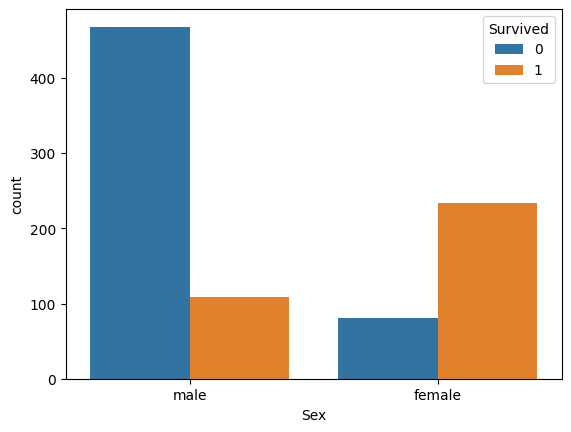

In [65]:
# 畫圖: matplotlib(basic) seaborn
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x=data["Sex"], hue=data["Survived"])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '(-0.512, 51.233]'),
  Text(1, 0, '(51.233, 102.466]'),
  Text(2, 0, '(102.466, 153.699]'),
  Text(3, 0, '(153.699, 204.932]'),
  Text(4, 0, '(204.932, 256.165]'),
  Text(5, 0, '(256.165, 307.398]'),
  Text(6, 0, '(307.398, 358.63]'),
  Text(7, 0, '(358.63, 409.863]'),
  Text(8, 0, '(409.863, 461.096]'),
  Text(9, 0, '(461.096, 512.329]')])

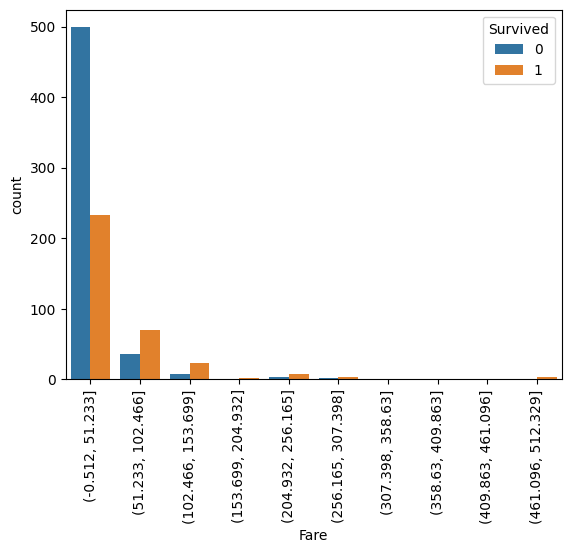

In [68]:
c = pd.cut(data["Fare"], bins=10)
sns.countplot(x=c, hue=data["Survived"])
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '10')])

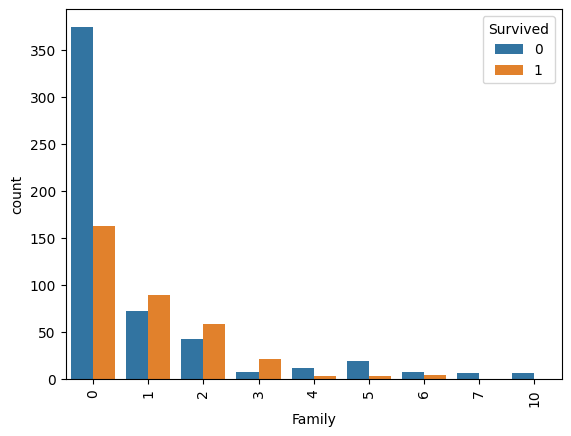

In [70]:
sns.countplot(x=x["Family"], hue=data["Survived"])
plt.xticks(rotation=90)

In [76]:
# !!! Imbalanced DataSet: 某一種類特別少
# 更換你的衡量標準: 準確率 -> precision/recall/f1-score
# precision(精確率): 你說o的, 有多少真的是o
# recall(召回率): 是o的東西, 你辨識出來了幾個
# TP: 預測值是Positive 真實值也是Positive
# FP: 預測值是Positive 真是值是Negative
# TN: 預測值是Negative 真實值是Negative
# FN: 預測值是Negative 真實值是Positive
# Precision: TP / (TP+FP)
# Recall: TP / (TP+FN)
# 這兩個是Trade-off, 這兩個不能兩個都高
# 提高精確率: 保守, 真的很確信才說是o
# 提高召回率: 激進, 你覺得有可能就說是o
# Covid-19: 初期(召回率高) 後期(精確率高)
# Imbalanced: 對於很稀少的東西, 至少要有一定的召回率
# 4, 6 -> 一次方平均: (4 + 6) / 2 = 5
# 二次方平均 (4^2 + 6^2)/2 -> 開根號 -> 5.x -> 往大的東西偏
# 負一次方平均 (1/4 + 1/6)/2 -> 分之一 -> 4.x -> 往小的東西篇
# f1 score = 2PRxRe/(PR+RE)
# RE->0 f1_score->0
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1)
clf = RandomForestClassifier(max_depth=7, n_estimators=95)
clf.fit(x_train, y_train)
pre = clf.predict(x_test)
print(classification_report(y_test, pre))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88        59
           1       0.83      0.65      0.73        31

    accuracy                           0.83        90
   macro avg       0.83      0.79      0.80        90
weighted avg       0.83      0.83      0.83        90



In [ ]:
# 距離有關的都要做scaling, 但是呢你分不出來就無腦做
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# fit: 只對訓練資料做一次(找出那行的最小/最大)
scaler.fit(total)
# 接下來都是transform
total_scaled = pd.DataFrame(scaler.transform(total),
                               columns=total.columns)
total_scaled

In [ ]:
x_scaled = total_scaled.iloc[:len(data)]
x_predict_scaled = total_scaled.iloc[len(data):]
x_predict_scaled

In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
params = {
    "n_neighbors":range(2, 30)
}
search = GridSearchCV(clf, params, cv=10, n_jobs=-1)
search.fit(x_scaled, y)
print("best score:", search.best_score_)
print("best params:", search.best_params_)

best score: 0.832796504369538
best params: {'n_neighbors': 7}


In [82]:
# 我其實是過了, 能在那個考試表現最好的參數是11
clf = KNeighborsClassifier(n_neighbors=11)
clf.fit(x_scaled, y)
ans = clf.predict(x_predict_scaled)
ans_df = pd.DataFrame({
    "PassengerId":predict["PassengerId"],
    "Survived":ans
})
ans_df.to_csv("knn.csv", encoding="utf-8", index=False)
ans_df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
